In [38]:
import pandas as pd
import matplotlib.pyplot as plt
from SALib.analyze import delta,pawn
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import matplotlib.lines as mlines
import scipy.stats

In [39]:
sheet_location = "/mnt/c/Users/kongr45gpen/Downloads/Taskov (4).xlsx"
df = pd.read_excel(sheet_location, sheet_name="Sensitivity Analysis").dropna()
df

,Project,Analysis Type,Number of Treatments,Development Time (hours),Cost (€),Risk (categorical)
1,ChipSat-1,Actual,4.0,478.0,8930.0,0.0
2,ChipSat-1,Counterfactual (SCS methodology used),6.0,590.0,6930.0,-2.0
3,ChipSat-1,Counterfactual (SCS methodology not used),0.0,948.0,6965.0,-2.0
4,AI4Space,Actual,5.0,468.0,4900.0,0.0
5,AI4Space,Counterfactual (SCS methodology used),6.0,492.0,3600.0,0.0
6,AI4Space,Counterfactual (SCS methodology not used),0.0,886.0,3600.0,1.0
7,POQUITO,Actual,6.0,450.0,12000.0,2.0
8,POQUITO,Counterfactual (SCS methodology not used),0.0,550.0,15000.0,2.0
9,ChiPySat,Actual,6.0,100.0,2000.0,2.0
10,ChiPySat,Counterfactual (SCS methodology not used),0.0,120.0,500.0,3.0


In [40]:
# Configuration
relative = True

df_copy = df.copy()

projects = df_copy['Project'].unique()
cmap = plt.get_cmap('tab10')
colors = {project: cmap(i) for i, project in enumerate(projects)}

label_map = {}

# TODO?
df_copy['Risk (categorical)'] += 1

# Normalise parameters for each project
if relative:
    for parameter in df_copy.columns[3:]:
        if 'categorical' not in parameter.lower() and 'risk' not in parameter.lower():
            label_map[parameter] = parameter.split('(')[0].strip() + " (relative)"
        else:
            label_map[parameter] = parameter

    for project in projects:
        project_mask = df_copy['Project'] == project
        for parameter in df_copy.columns[3:]:
            base_value = df_copy.loc[project_mask, parameter].iloc[0]
            df_copy.loc[project_mask, parameter] = (df_copy.loc[project_mask, parameter]) / base_value
else:
    for parameter in df_copy.columns[3:]:
        label_map[parameter] = parameter


specifier = "_relative" if relative else "_absolute"

(label_map, df_copy)

({'Development Time (hours)': 'Development Time (relative)',
  'Cost (€)': 'Cost (relative)',
  'Risk (categorical)': 'Risk (categorical)'},
       Project                              Analysis Type  \
 1   ChipSat-1                                     Actual   
 2   ChipSat-1      Counterfactual (SCS methodology used)   
 3   ChipSat-1  Counterfactual (SCS methodology not used)   
 4    AI4Space                                     Actual   
 5    AI4Space      Counterfactual (SCS methodology used)   
 6    AI4Space  Counterfactual (SCS methodology not used)   
 7     POQUITO                                     Actual   
 8     POQUITO  Counterfactual (SCS methodology not used)   
 9    ChiPySat                                     Actual   
 10   ChiPySat  Counterfactual (SCS methodology not used)   
 
     Number of Treatments  Development Time (hours)  Cost (€)  \
 1                    4.0                  1.000000  1.000000   
 2                    6.0                  1.234310  0.7

## Statistical analysis

Parameter: Development Time (relative)
Max treatments: 6.0
MannwhitneyuResult(statistic=np.float64(14.0), pvalue=np.float64(0.11428571428571428))
TtestResult(statistic=np.float64(2.3088843535266452), pvalue=np.float64(0.09342070626959406), df=np.float64(3.416081309743712))
Parameter: Cost (relative)
Max treatments: 6.0
MannwhitneyuResult(statistic=np.float64(6.5), pvalue=np.float64(0.8857142857142857))
TtestResult(statistic=np.float64(-0.5731921009989682), pvalue=np.float64(0.599401081743005), df=np.float64(3.716331974744812))
Parameter: Risk (categorical)
Max treatments: 6.0
MannwhitneyuResult(statistic=np.float64(11.0), pvalue=np.float64(0.4857142857142857))
TtestResult(statistic=np.float64(0.4082482904638629), pvalue=np.float64(0.698116858900156), df=np.float64(5.647058823529412))


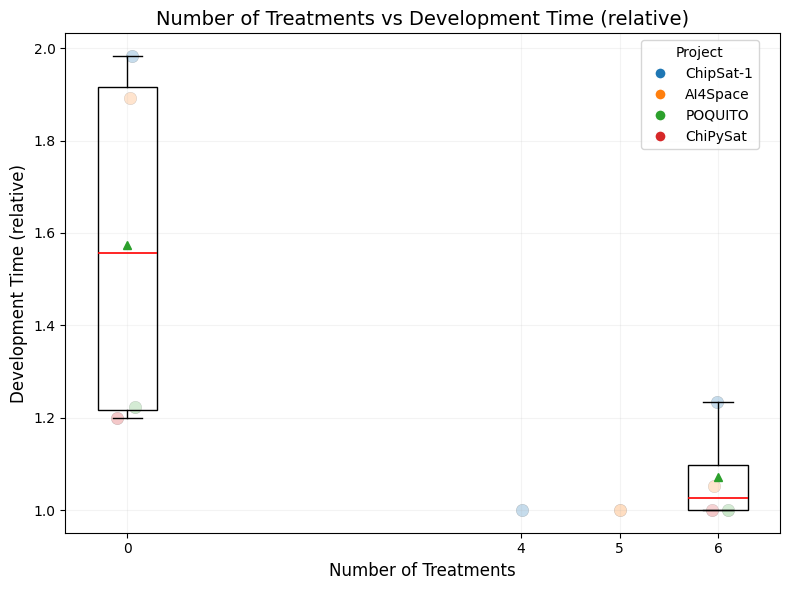

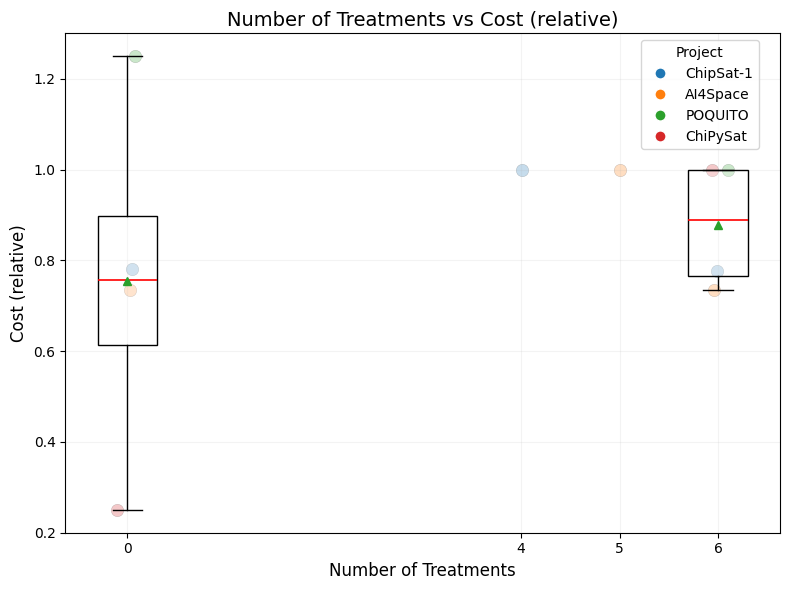

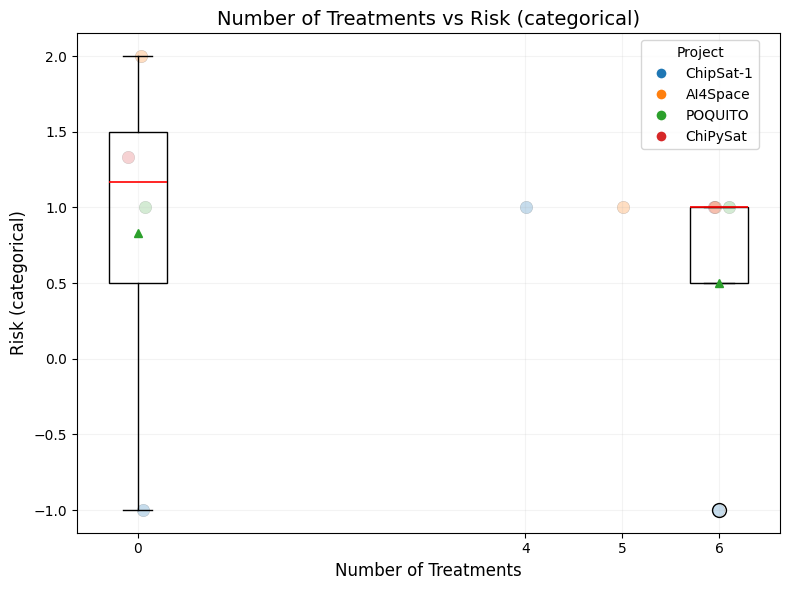

In [41]:

for parameter in df_copy.columns[3:]:
    parameter_alias = parameter.split()[0].lower()
    label = label_map[parameter]

    treatments = np.sort(df_copy['Number of Treatments'].unique())
    data_by_t = [df_copy.loc[df_copy['Number of Treatments'] == t, parameter].values for t in treatments]

    fig, ax = plt.subplots(figsize=(8, 6))

    # scatter background: jitter points and color by project
    rng = np.random.default_rng(0)
    for proj in projects:
        proj_mask = df_copy['Project'] == proj
        xs = df_copy.loc[proj_mask, 'Number of Treatments'].values
        ys = df_copy.loc[proj_mask, parameter].values
        if len(xs):
            jitter = rng.normal(0, 0.08, size=len(xs))
            ax.scatter(xs + jitter, ys, color=colors.get(proj, 'gray'), alpha=0.25, s=80, edgecolors='k', linewidths=0.3, zorder=1)

    # filter treatments with 1 data only
    data_by_t = [data if len(data) > 1 else np.array([]) for data in data_by_t]

    bp = ax.boxplot(data_by_t, positions=treatments, widths=0.6, patch_artist=True, notch=False, manage_ticks=False, zorder=2, showmeans=True)
    # style boxes to be transparent so background points remain visible
    for box in bp['boxes']:
        box.set(facecolor=(1, 1, 1, 0.2), edgecolor='black', linewidth=1.0)
    # for whisker in bp['whiskers']:
    #     whisker.set(color='black', linewidth=0.8)
    # for cap in bp['caps']:
    #     cap.set(color='black', linewidth=0.8)
    for median in bp['medians']:
        median.set(color='red', linewidth=1.2)
    for flier in bp['fliers']:
        flier.set(marker='o', color='black', alpha=1, linewidth=1, ms=10)

    ax.set_xlabel('Number of Treatments', fontsize=12)
    ax.set_ylabel(label, fontsize=12)
    ax.set_title(f'Number of Treatments vs {label}', fontsize=14)
    ax.set_xticks(treatments)
    ax.grid(True, alpha=0.15)

    # legend for projects
    handles = [mlines.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[p], markersize=8, label=p) for p in projects]
    ax.legend(handles=handles, title='Project', bbox_to_anchor=(0.98, 1), loc='upper right')

    plt.tight_layout()
    plt.savefig(f"sensitivity_boxplot_{parameter_alias}{specifier}.pdf", dpi=300)
    #plt.show()

    print(f"Parameter: {label}")
    print(f"Max treatments: {df_copy['Number of Treatments'].max()}")
    # Mann-Whitney U test
    print(scipy.stats.mannwhitneyu(df_copy.loc[df_copy['Number of Treatments'] == 0, parameter],
                                   df_copy.loc[df_copy['Number of Treatments'] == df_copy['Number of Treatments'].max(), parameter],
                                   alternative='two-sided',
                                   method='exact'))
    # Student T-test
    print(scipy.stats.ttest_ind(df_copy.loc[df_copy['Number of Treatments'] == 0, parameter],
                                df_copy.loc[df_copy['Number of Treatments'] == df_copy['Number of Treatments'].max(), parameter],
                                alternative='two-sided',
                                equal_var=False))

## Sensitivity analysis

Parameter: Development Time (hours)
  Min: 1.0
  Max: 1.9832635983263598
  Mean: 1.258423988842399
  Std: 0.371727251971799

[1 1 1 2 2 2 3 3 4 4]
   number of treatments  project #  Development Time (relative)
0                   4.0          1                     1.000000
1                   6.0          1                     1.234310
2                   0.0          1                     1.983264
3                   5.0          2                     1.000000
4                   6.0          2                     1.051282
5                   0.0          2                     1.893162
6                   6.0          3                     1.000000
7                   0.0          3                     1.222222
8                   6.0          4                     1.000000
9                   0.0          4                     1.200000
=== ANALYSIS FOR PARAMETER: Development Time (hours) ===
                       minimum      mean  median   maximum        CV     stdev
number of tre

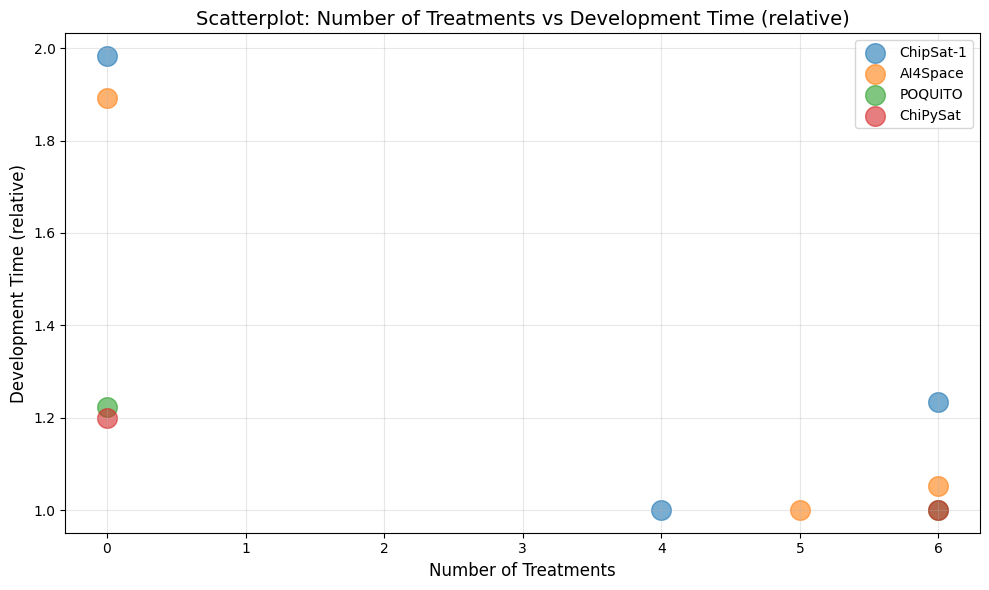

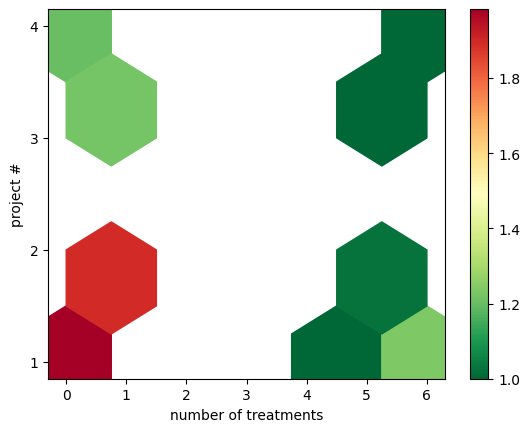

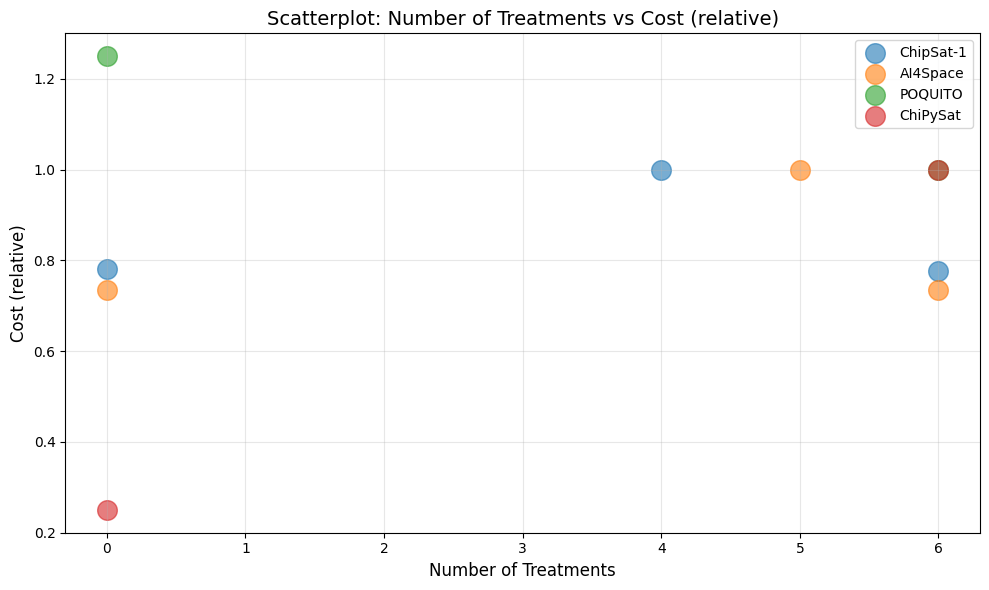

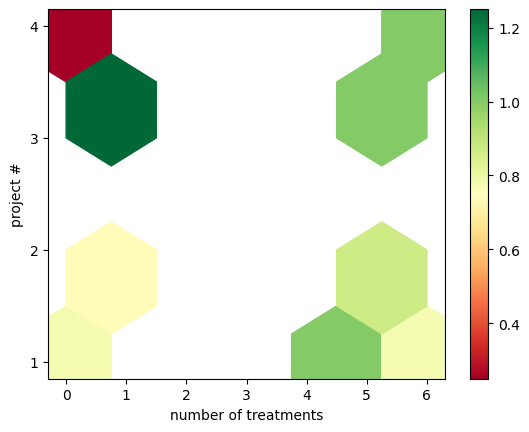

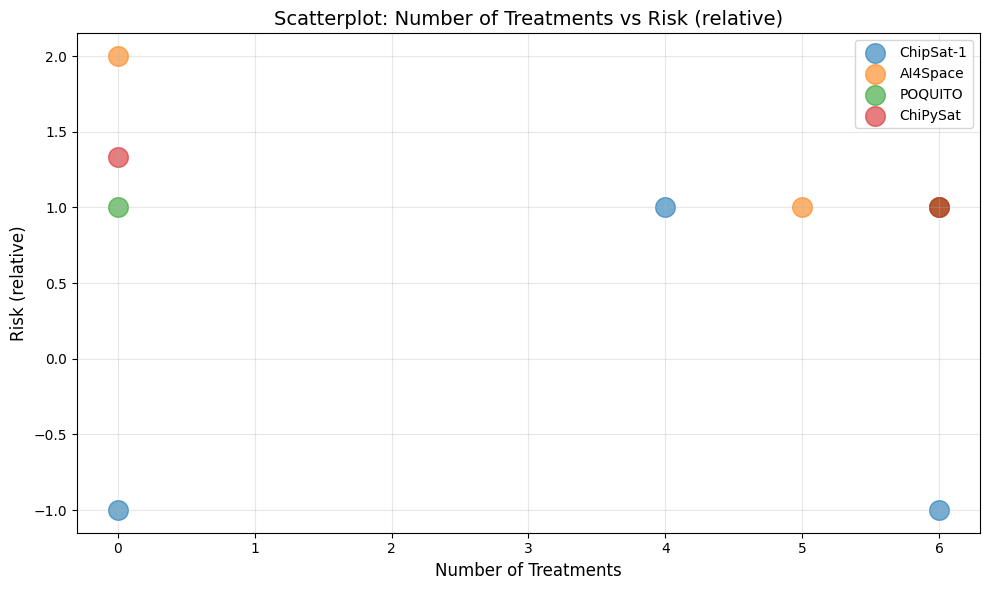

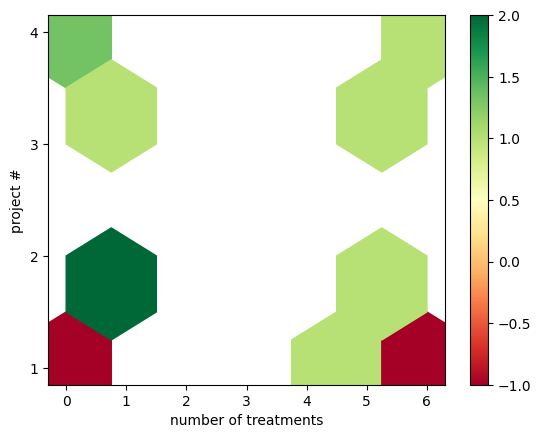

In [42]:
# Sensitivity analysis

for parameter in df_copy.columns[3:]:
    print(f"Parameter: {parameter}")
    print(f"  Min: {df_copy[parameter].min()}")
    print(f"  Max: {df_copy[parameter].max()}")
    print(f"  Mean: {df_copy[parameter].mean()}")
    print(f"  Std: {df_copy[parameter].std()}")
    print()

    fig, ax = plt.subplots(figsize=(10, 6))
    
    for project in projects:
        project_data = df_copy[df_copy['Project'] == project]

        ax.scatter(project_data['Number of Treatments'], 
                project_data[parameter], 
                s=200, alpha=0.6, 
                color=colors[project], 
                label=project)
    
    # Add labels for each point
    for idx, row in df_copy.iterrows():
        label = row['Project'] + " " + row['Analysis Type']
        #ax.annotate(label, (row['Number of Treatments'], row[parameter]), 
        #           fontsize=9, alpha=0.7)

    parameter_alias = parameter.split()[0].lower()
    label = parameter
    if relative:
        label = label.split('(')[0].strip() + " (relative)"
    
    ax.set_xlabel('Number of Treatments', fontsize=12)
    ax.set_ylabel(label, fontsize=12)
    ax.set_title(f'Scatterplot: Number of Treatments vs {label}', fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    #plt.show()
    plt.savefig(f"sensitivity_scatter_{parameter_alias}.pdf", dpi=150)


    # SENSITIVTY ANALYSIS
    # x1 = number of treatments
    x1 = df_copy['Number of Treatments'].values
    # x2 = project index
    projector = lambda p: (np.where(projects == p)[0])[0]+1
    projectors = np.vectorize(projector)
    x2 = projectors(df_copy['Project'])
    print(x2)
    # y = output value
    y = df_copy[parameter].values

    # Create a list of (x1, x2, y) tuples
    inputs = list(zip(x1, x2))
    outputs = list(zip(x1, x2, y))
    df_sens = pd.DataFrame(outputs, columns=['number of treatments', 'project #', label])
    print(df_sens)

    cmap = 'RdYlGn_r' if 'time' in label.lower() else 'RdYlGn'

    plt_sens = df_sens.plot.hexbin(x='number of treatments', y='project #', C=label, gridsize=len(projects), cmap=cmap, sharex=False)
    plt_sens.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    specifier = "_relative" if relative else "_absolute"
    plt_sens.figure.savefig(f"sensitivity_hexbin_{parameter_alias}{specifier}.pdf", dpi=300)

    problem = {
        'num_vars': 2,
        'names': ['number of treatments', 'project #'],
        # 'bounds': [[1, 5], [1, len(projects)]]
    }

    print(f"=== ANALYSIS FOR PARAMETER: {parameter} ===")
    analysis = pawn.analyze(problem, np.array(inputs), np.array(y), print_to_console=True)
    print("")

In [ ]:
# Experimental sheet (do not use)

from SALib.sample import latin
from SALib.test_functions import Ishigami
from SALib.analyze import dgsm,hdmr,discrepancy,delta,pawn
import numpy as np
import pandas as pd

problem = {
    'num_vars': 3,
    'names': ['x1', 'x2', 'x3'],
    'bounds': [[-3.14159265359, 3.14159265359],
               [-3.14159265359, 3.14159265359],
               [-3.14159265359, 3.14159265359]]
}

X = latin.sample(problem, 1000)
#Y = Ishigami.evaluate(X)

def model_one(x):
    return x[0] + 2 * (x[1] ** 2)
Y = np.array([model_one(x) for x in X])

# The delta method provides nice information about how much an input affects variation in the output in terms of both importance and impact. But it doesn't seem to be working well for small sample sizes.
Si = delta.analyze(problem, X, Y, print_to_console=True)
Si.plot()

# Pawn is more robust to small sample sizes, but doesn't provide confidence intervals.
Si = pawn.analyze(problem, X, Y, print_to_console=True)
Si.plot()

df_sens = pd.DataFrame(X, columns=problem['names'])
df_sens['output'] = Y

plt_sens = df_sens.plot.hexbin(x='x1', y='x2', C='output', gridsize=6, cmap='RdYlGn', sharex=False)